# Research Notebook: Pairs Trading
Based on "Pairs Trading in Crypto" by Stoikov, et al. (2025)

### Imports

In [ ]:
import requests
import pandas as pd
import numpy as np
import time
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import itertools
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from statsmodels.tsa.stattools import coint
from tqdm.notebook import tqdm

plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.6f}'.format)

### Fetching candlestick data from Binance
Fetch historical price data for (nearly) all coins available on Roostoo. Coins are categorized following research paper methodology.

In [3]:
CATEGORIZED_SYMBOLS = {
    "layer_1": {
        "BTC": "BTCUSDT", "ETH": "ETHUSDT", "SOL": "SOLUSDT", "BNB": "BNBUSDT",
        "ADA": "ADAUSDT", "TRX": "TRXUSDT", "DOT": "DOTUSDT", "SUI": "SUIUSDT",
        "NEAR": "NEARUSDT", "AVAX": "AVAXUSDT", "TON": "TONUSDT", "XRP": "XRPUSDT",
        "DOGE": "DOGEUSDT", "MATIC": "POLUSDT", "BCH": "BCHUSDT", "LTC": "LTCUSDT",
        "APT": "APTUSDT", "ATOM": "ATOMUSDT", "HBAR": "HBARUSDT"
    },
    "layer_2": {
        "POL": "POLUSDT", "ARB": "ARBUSDT", "OP": "OPUSDT", "STRK": "STRKUSDT",
        "ZK": "ZKUSDT", "METIS": "METISUSDT", "MANTA": "MANTAUSDT",
        "IMX": "IMXUSDT", "SKL": "SKLUSDT"
    },
    "defi": {
        "AAVE": "AAVEUSDT", "ENA": "ENAUSDT", "UNI": "UNIUSDT", "MKR": "MKRUSDT",
        "LINK": "LINKUSDT", "CRV": "CRVUSDT", "JUP": "JUPUSDT", "LDO": "LDOUSDT",
        "RAY": "RAYUSDT", "CAKE": "CAKEUSDT", "COMP": "COMPUSDT", "SNX": "SNXUSDT"
    },
    "liquid_staking_restaking": {
        "LDO": "LDOUSDT", "ETHFI": "ETHFIUSDT", "REZ": "REZUSDT", "PENDLE": "PENDLEUSDT",
        "EIGEN": "EIGENUSDT", "BB": "BBUSDT"
    },
    "memes": {
        "PEPE": "PEPEUSDT", "SHIB": "SHIBUSDT", "WIF": "WIFUSDT", "BONK": "BONKUSDT",
        "FLOKI": "FLOKIUSDT", "BOME": "BOMEUSDT", "MEME": "MEMEUSDT", "TURBO": "TURBOUSDT"
    },
    "ai_and_depin": {
        "FET": "FETUSDT", "RNDR": "RENDERUSDT", "TAO": "TAOUSDT", "GRT": "GRTUSDT",
        "AR": "ARUSDT", "THETA": "THETAUSDT", "FIL": "FILUSDT", "JASMY": "JASMYUSDT"
    }
}

# Flatten the nested dictionary for the data fetcher
SYMBOLS = {}
for category, tokens in CATEGORIZED_SYMBOLS.items():
    for name, ticker in tokens.items():
        SYMBOLS[name] = ticker

print(f"Number of symbols: {len(SYMBOLS)}")

INTERVAL  = "1h"
DAYS_BACK = 1000

BASE_URL = "https://api.binance.com/api/v3/klines"

Number of symbols: 61


In [4]:
def fetch_binance_klines(symbol: str, interval: str, days: int) -> pd.DataFrame:
    """
    Fetch historical kline (candlestick) data from Binance public API.
    No API key required.

    Automatically paginates through the 1000-candle-per-request limit
    so you can fetch arbitrarily long histories (e.g. 30 days of 1m data).

    Returns a DataFrame with columns:
        open_time, open, high, low, close, volume, close_time
    """
    end_ms   = int(time.time() * 1000)
    start_ms = int((time.time() - days * 86400) * 1000)
    limit    = 1000

    all_rows = []
    cursor   = start_ms

    while cursor < end_ms:
        params = {
            "symbol":    symbol,
            "interval":  interval,
            "startTime": cursor,
            "endTime":   end_ms,
            "limit":     limit,
        }
        resp = requests.get(BASE_URL, params=params)
        resp.raise_for_status()
        batch = resp.json()

        if not batch:
            break

        all_rows.extend(batch)
        # advance cursor past the last candle's open_time
        cursor = batch[-1][0] + 1
        time.sleep(0.1)  # rate-limit courtesy

    cols = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_vol", "trades", "taker_buy_base",
        "taker_buy_quote", "ignore",
    ]
    df = pd.DataFrame(all_rows, columns=cols)
    df["open_time"]  = pd.to_datetime(df["open_time"],  unit="ms")
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms")

    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = df[col].astype(float)

    return df[["open_time", "open", "high", "low", "close", "volume", "close_time"]]

In [5]:
CACHE_FILE = f"klines_cache_{DAYS_BACK}d.pkl"

if os.path.exists(CACHE_FILE):
    print(f"Loading cached data from {CACHE_FILE}...")
    with open(CACHE_FILE, "rb") as f:
        raw_data = pickle.load(f)
else:
    raw_data = {}

# ── Pull data for every symbol ────────────────────────────────
for name, ticker in SYMBOLS.items():
    if name in raw_data and len(raw_data[name]) > 0:
        print(f"Loaded cached {name:5s} ({ticker}) ... {len(raw_data[name])} candles")
    else:
        print(f"Fetching {name:5s} ({ticker}) ...", end=" ")
        raw_data[name] = fetch_binance_klines(ticker, INTERVAL, DAYS_BACK)
        print(f"{len(raw_data[name])} candles")
        with open(CACHE_FILE, "wb") as f:
            pickle.dump(raw_data, f)

print("\n✅ All data loaded successfully.")

Loading cached data from klines_cache_1000d.pkl...
Loaded cached BTC   (BTCUSDT) ... 24000 candles
Loaded cached ETH   (ETHUSDT) ... 24000 candles
Loaded cached SOL   (SOLUSDT) ... 24000 candles
Loaded cached BNB   (BNBUSDT) ... 24000 candles
Loaded cached ADA   (ADAUSDT) ... 24000 candles
Loaded cached TRX   (TRXUSDT) ... 24000 candles
Loaded cached DOT   (DOTUSDT) ... 24000 candles
Loaded cached SUI   (SUIUSDT) ... 24000 candles
Loaded cached NEAR  (NEARUSDT) ... 24000 candles
Loaded cached AVAX  (AVAXUSDT) ... 24000 candles
Loaded cached TON   (TONUSDT) ... 14037 candles
Loaded cached XRP   (XRPUSDT) ... 24000 candles
Loaded cached DOGE  (DOGEUSDT) ... 24000 candles
Loaded cached MATIC (POLUSDT) ... 13173 candles
Loaded cached BCH   (BCHUSDT) ... 24000 candles
Loaded cached LTC   (LTCUSDT) ... 24000 candles
Loaded cached APT   (APTUSDT) ... 24000 candles
Loaded cached ATOM  (ATOMUSDT) ... 24000 candles
Loaded cached HBAR  (HBARUSDT) ... 24000 candles
Loaded cached POL   (POLUSDT) ..

In [26]:
# Calculate expected candles based on hours per day (24)
EXPECTED_CANDLES = DAYS_BACK * 24 

# How many days of data we want to train & test this on
DAYS = 100

close_prices = pd.DataFrame({
    name: df.set_index("open_time")["close"]
    for name, df in raw_data.items() 
    if name in SYMBOLS and len(df) >= EXPECTED_CANDLES
})

close_prices.index.name = "date"
close_prices = close_prices.dropna()

cutoff_date = close_prices.index.max() - pd.Timedelta(days=DAYS)
close_prices = close_prices[close_prices.index >= cutoff_date]

print(f"Close prices shape: {close_prices.shape}")
close_prices.head()

Close prices shape: (2401, 39)


,BTC,ETH,SOL,BNB,ADA,TRX,DOT,SUI,NEAR,AVAX,...,SNX,PEPE,SHIB,FLOKI,FET,GRT,AR,THETA,FIL,JASMY
date,,,,,,,,,,,,,,,,,,,,,
2025-12-06 05:00:00,89604.980000,3037.460000,133.070000,883.390000,0.414200,0.287500,2.108000,1.540200,1.677000,13.310000,...,0.491000,0.000004,0.000008,0.000045,0.234700,0.045170,3.960000,0.332000,1.481000,0.007010
2025-12-06 06:00:00,89688.650000,3039.430000,132.950000,884.690000,0.412500,0.288400,2.105000,1.537900,1.678000,13.250000,...,0.491000,0.000004,0.000008,0.000045,0.235900,0.045340,3.970000,0.334000,1.478000,0.006960
2025-12-06 07:00:00,89597.130000,3026.250000,132.720000,884.760000,0.411700,0.288600,2.105000,1.524400,1.683000,13.230000,...,0.489000,0.000004,0.000008,0.000045,0.236500,0.045460,3.990000,0.332000,1.480000,0.006940
2025-12-06 08:00:00,89277.140000,3014.450000,131.990000,878.400000,0.410200,0.287900,2.089000,1.511400,1.683000,13.180000,...,0.487000,0.000004,0.000008,0.000045,0.234500,0.045260,3.970000,0.331000,1.469000,0.006900
2025-12-06 09:00:00,89574.120000,3030.000000,132.520000,882.830000,0.412700,0.288900,2.102000,1.518700,1.707000,13.280000,...,0.490000,0.000004,0.000008,0.000045,0.235900,0.045400,3.980000,0.332000,1.479000,0.006910


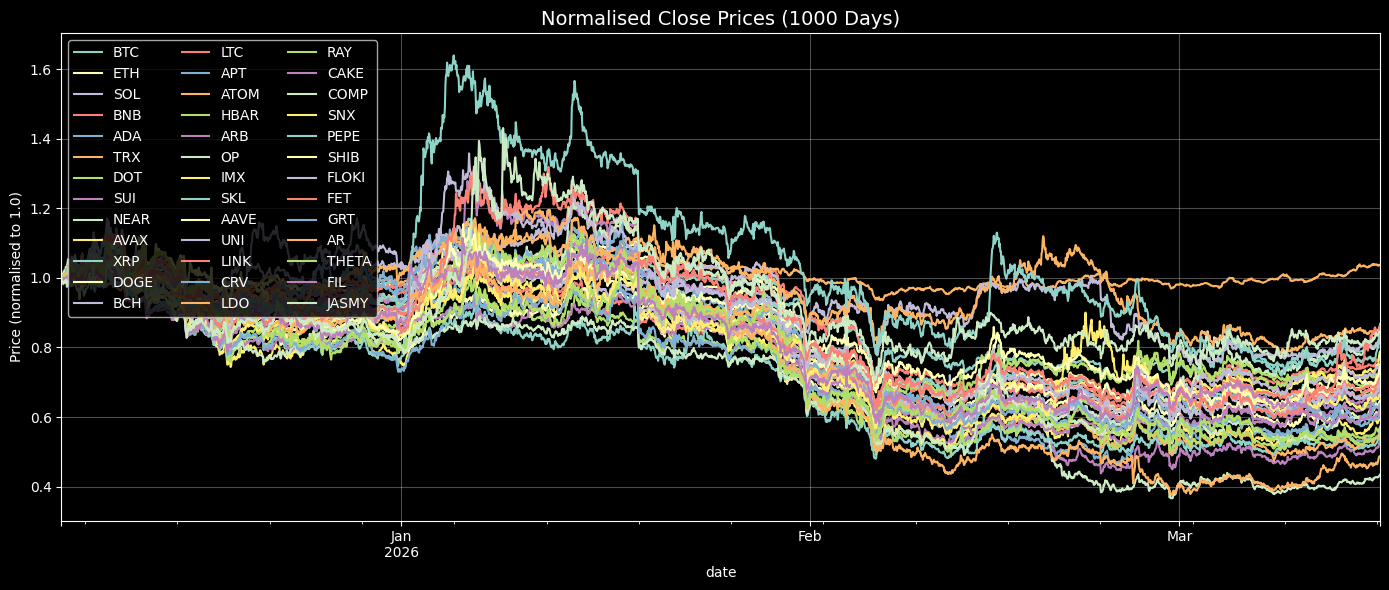

In [27]:
# Normalise all series to start at 1.0 for visual comparison
normalised = close_prices / close_prices.iloc[0]

fig, ax = plt.subplots(figsize=(14, 6))
normalised.plot(ax=ax, linewidth=1.5)
ax.set_title(f"Normalised Close Prices ({DAYS_BACK} Days)", fontsize=14)
ax.set_ylabel("Price (normalised to 1.0)")
ax.legend(loc="upper left", ncol=3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Get log prices & returns

In [116]:
# Split Data: 80-20
split_idx = int(len(close_prices) * 0.9)
train_close_prices = close_prices.iloc[:split_idx]
test_close_prices = close_prices.iloc[split_idx:]

print(f"Train data shape: {train_close_prices.shape}")
print(f"Test data shape: {test_close_prices.shape}")

# Log prices & returns
log_prices  = np.log(train_close_prices).dropna()
log_returns = np.log(close_prices).diff().dropna()

log_returns.head()
log_prices.head()

Train data shape: (2160, 39)
Test data shape: (241, 39)


,BTC,ETH,SOL,BNB,ADA,TRX,DOT,SUI,NEAR,AVAX,...,SNX,PEPE,SHIB,FLOKI,FET,GRT,AR,THETA,FIL,JASMY
date,,,,,,,,,,,,,,,,,,,,,
2025-12-06 05:00:00,11.403166,8.018777,4.890875,6.783767,-0.881406,-1.246532,0.745740,0.431912,0.517006,2.588516,...,-0.711311,-12.338462,-11.690857,-10.010850,-1.449447,-3.097322,1.376244,-1.102620,0.392718,-4.960418
2025-12-06 06:00:00,11.404100,8.019425,4.889973,6.785237,-0.885519,-1.243407,0.744315,0.430418,0.517603,2.583998,...,-0.711311,-12.338462,-11.690857,-10.010627,-1.444347,-3.093566,1.378766,-1.096614,0.390690,-4.967576
2025-12-06 07:00:00,11.403079,8.015080,4.888242,6.785316,-0.887460,-1.242714,0.744315,0.421601,0.520578,2.582487,...,-0.715393,-12.345335,-11.692052,-10.009515,-1.441807,-3.090922,1.383791,-1.102620,0.392042,-4.970454
2025-12-06 08:00:00,11.399501,8.011173,4.882726,6.778102,-0.891110,-1.245142,0.736685,0.413036,0.520578,2.578701,...,-0.719491,-12.347636,-11.698051,-10.017777,-1.450300,-3.095332,1.378766,-1.105637,0.384582,-4.976234
2025-12-06 09:00:00,11.402822,8.016318,4.886734,6.783133,-0.885034,-1.241675,0.742889,0.417855,0.534737,2.586259,...,-0.713350,-12.343039,-11.690857,-10.011296,-1.444347,-3.092243,1.381282,-1.102620,0.391366,-4.974786


### Generate pairs within same category

In [117]:
# 1. Generate Same-Category Pairs
candidate_pairs = []
for category, tokens in CATEGORIZED_SYMBOLS.items():
    names = list(tokens.keys())
    # Create all possible unique pairs within this specific category
    category_pairs = list(itertools.combinations(names, 2))
    candidate_pairs.extend(category_pairs)

print(f"Total candidate pairs from same categories: {len(candidate_pairs)}")

Total candidate pairs from same categories: 344


### Correlation, cointegration, IC tests

In [1]:
correlated_pairs = []
for coin_a, coin_b in tqdm(candidate_pairs, desc="Analyzing correlation of pairs..."):
    if coin_a in log_prices.columns and coin_b in log_prices.columns:
        corr_log = log_prices[coin_a].corr(log_prices[coin_b])
        corr_ret = log_returns[coin_a].corr(log_returns[coin_b])
        
        # The paper's strict thresholds
        if corr_log > 0.9 and corr_ret > 0.5:
            correlated_pairs.append((coin_a, coin_b))

print(f"Pairs surviving correlation screening: {len(correlated_pairs)}")

NameError: name 'tqdm' is not defined

Note: Cointegration testing was not part of the original research paper methodology, but I added it here to be more robust

In [119]:
def check_cointegration(series_a, series_b, significance_level=0.05):
    """
    Runs the Engle-Granger test for cointegration.
    Returns True if the pairs are cointegrated, along with the p-value.
    """
    # The coint function automatically runs the OLS regression and ADF test
    score, p_value, _ = coint(series_a, series_b)
    
    is_cointegrated = p_value < significance_level
    return is_cointegrated, p_value

# How to use it on your surviving correlated_pairs:
robust_pairs = []
print("Testing for strict cointegration...")

for coin_a, coin_b in correlated_pairs:
    is_coint, p_val = check_cointegration(log_prices[coin_a], log_prices[coin_b])
    
    if is_coint:
        print(f"✅ {coin_a}-{coin_b} passed (p-value: {p_val:.4f})")
        robust_pairs.append((coin_a, coin_b))
    else:
        print(f"❌ {coin_a}-{coin_b} failed (p-value: {p_val:.4f})")

print(f"\nPairs surviving cointegration: {len(robust_pairs)}")

Testing for strict cointegration...
✅ BTC-ETH passed (p-value: 0.0052)
✅ BTC-SOL passed (p-value: 0.0088)
✅ BTC-BNB passed (p-value: 0.0490)
❌ BTC-ADA failed (p-value: 0.4498)
❌ BTC-DOT failed (p-value: 0.3333)
❌ BTC-SUI failed (p-value: 0.1941)
❌ BTC-NEAR failed (p-value: 0.5872)
❌ BTC-AVAX failed (p-value: 0.2502)
❌ BTC-XRP failed (p-value: 0.2935)
❌ BTC-DOGE failed (p-value: 0.1988)
❌ BTC-LTC failed (p-value: 0.6163)
❌ BTC-APT failed (p-value: 0.0722)
✅ ETH-SOL passed (p-value: 0.0210)
❌ ETH-BNB failed (p-value: 0.1594)
❌ ETH-ADA failed (p-value: 0.2803)
❌ ETH-DOT failed (p-value: 0.4054)
❌ ETH-SUI failed (p-value: 0.2946)
❌ ETH-NEAR failed (p-value: 0.6411)
❌ ETH-AVAX failed (p-value: 0.1977)
✅ ETH-XRP passed (p-value: 0.0065)
❌ ETH-DOGE failed (p-value: 0.1000)
❌ ETH-LTC failed (p-value: 0.5752)
❌ ETH-APT failed (p-value: 0.1355)
❌ SOL-BNB failed (p-value: 0.0566)
❌ SOL-ADA failed (p-value: 0.2871)
❌ SOL-DOT failed (p-value: 0.3880)
❌ SOL-SUI failed (p-value: 0.0988)
❌ SOL-NEAR fa

In [120]:
# T1: Rolling regression windows (Lookback)
# 7d, 15d, 30d
t1_windows = [168, 360, 720] 

# T2: Forecast horizons (Prediction)
# 1h, 3h, 6h, 12h, 1d, 3d, 10d (in hours)
t2_horizons = [1, 3, 6, 12, 24, 72, 240]

def calculate_pair_ic(coin_a, coin_b, log_prices_df, window, horizon):
    """
    Calculates the Information Coefficient (IC) for a single combination of T1 and T2.
    """
    y = log_prices_df[coin_a]
    x_col = log_prices_df[coin_b]
    X = sm.add_constant(x_col)
    
    # Run rolling regression to find the moving relationship
    roll_reg = RollingOLS(y, X, window=window).fit()
    params = roll_reg.params
    
    # 1. Current spread using CURRENT parameters 
    # (No need to shift backwards, RollingOLS already prevents lookahead bias)
    current_spread = y - (params['const'] + params[coin_b] * x_col)
    
    # 2. Standardize to get the Z-score
    # We use np.sqrt(roll_reg.mse_resid) to get the in-sample regression volatility
    z_score = current_spread / np.sqrt(roll_reg.mse_resid)
    
    # 3. Future spread using CURRENT parameters applied to FUTURE prices
    future_y = y.shift(-horizon)
    future_x = x_col.shift(-horizon)
    future_spread_locked = future_y - (params['const'] + params[coin_b] * future_x)
    
    # 4. Calculate future return of the spread (Future state - Current state)
    future_spread_return = future_spread_locked - current_spread
    
    # Combine and drop empty rows
    valid_data = pd.concat([z_score, future_spread_return], axis=1).dropna()
    valid_data.columns = ['z_score', 'future_return']
    
    # Calculate correlation (IC)
    if len(valid_data) > 100: 
        ic = valid_data['z_score'].corr(valid_data['future_return'])
        return ic
    
    return np.nan

In [121]:
best_pair_results = []
top_pairs = []

print("Running grid search for Best IC...")

for coin_a, coin_b in tqdm(robust_pairs, desc="Analyzing IC of pairs"):
    best_ic = float('inf')
    best_t1, best_t2 = None, None
    
    # Inner grid search
    for t1 in t1_windows:
        for t2 in t2_horizons:
            current_ic = calculate_pair_ic(coin_a, coin_b, log_prices, window=t1, horizon=t2)
            
            # Look for the MOST NEGATIVE Information Coefficient
            if pd.notna(current_ic) and current_ic < best_ic:
                best_ic = current_ic
                best_t1 = t1
                best_t2 = t2
                
    best_pair_results.append({
        'Pair': f"{coin_a}-{coin_b}",
        'Best IC': best_ic,
        'Best T1 (hours)': best_t1,
        'Best T2 (hours)': best_t2
    })
    top_pairs.append([coin_a, coin_b])

Running grid search for Best IC...


Analyzing IC of pairs:   0%|          | 0/17 [00:00<?, ?it/s]

In [122]:
# Create a DataFrame and rank by the most negative IC
results_df = pd.DataFrame(best_pair_results)
if not results_df.empty:
    results_df = results_df.sort_values(by='Best IC', ascending=True).reset_index(drop=True)
    print("\nTop Mean-Reverting Pairs (Ranked by Best IC):")
    print(results_df.head(10))
else:
    print("No pairs survived the filtering process.")


Top Mean-Reverting Pairs (Ranked by Best IC):
        Pair   Best IC  Best T1 (hours)  Best T2 (hours)
0    SUI-XRP -0.672759              720              240
1  AAVE-COMP -0.646683              720               72
2    IMX-SKL -0.645214              720              240
3  LINK-COMP -0.626644              720              240
4    ETH-XRP -0.530703              360              240
5    ETH-SOL -0.529810              360              240
6    SOL-XRP -0.480769              168              240
7    BTC-ETH -0.464433              360               72
8   AVAX-XRP -0.460673              720              240
9    ARB-SKL -0.458621              720              240


# Backtest going long and short (research paper setup)
Note: Roostoo doesn't allow short-selling, this backtest is just for reference

In [ ]:
def run_paper_backtest(coin_a, coin_b, price_df, window=720, z_entry=2.0, z_exit=0.0):
    """
    Simulates the exact Event-Driven Backtest (Algorithm 1) from the research paper.
    Includes short selling, hedge-weighted sizing, stop-losses, and cooldowns.
    """
    # Fixed parameters from the research paper
    gamma_sl = 0.20          # 20% stop-loss threshold
    delta_cool = 120         # 5 days cooldown in hours
    gamma_de = 0.20          # 20% permanent deactivation threshold
    gamma_fee = 0.0005       # 0.05% taker fee rate
    leverage = 1.0           # 5x leverage
    starting_equity = 1000000.0 # $1,000,000 starting capital
    
    # 1. Calculate the rolling Z-Score safely
    log_prices = np.log(price_df[[coin_a, coin_b]]).dropna()
    y = log_prices[coin_a]
    x_col = log_prices[coin_b]
    X = sm.add_constant(x_col)
    
    roll_reg = RollingOLS(y, X, window=window).fit()
    
    # Get moving parameters
    betas = roll_reg.params[coin_b]
    current_spread = y - (roll_reg.params['const'] + betas * x_col)
    spread_std = np.sqrt(roll_reg.mse_resid)
    z_scores = (current_spread / spread_std).dropna()
    
    # Align prices and parameters with valid Z-score dates
    aligned_prices = price_df.loc[z_scores.index]
    betas = betas.loc[z_scores.index]
    
    # 2. State Tracking Variables
    equity = starting_equity
    state = 'flat' # Can be 'flat', 'long_spread', 'short_spread'
    deactivated = False
    cooldown_until = None
    
    q_a = 0.0
    q_b = 0.0
    entry_price_a = 0.0
    entry_price_b = 0.0
    entry_equity = 0.0
    
    z_prev = 0.0
    
    equity_curve = []
    trades = []
    
    # 3. Time-Step Simulation
    for current_time, z_t in z_scores.items():
        p_a = aligned_prices.loc[current_time, coin_a]
        p_b = aligned_prices.loc[current_time, coin_b]
        beta_t = betas.loc[current_time]
        
        # Calculate current Mark-to-Market Equity
        mtm_equity = equity
        if state == 'long_spread':
            # Long A, Short B
            unrealized_pnl = (p_a - entry_price_a) * q_a + (entry_price_b - p_b) * q_b
            mtm_equity = equity + unrealized_pnl
        elif state == 'short_spread':
            # Short A, Long B
            unrealized_pnl = (entry_price_a - p_a) * q_a + (p_b - entry_price_b) * q_b
            mtm_equity = equity + unrealized_pnl
            
        equity_curve.append({'time': current_time, 'equity': mtm_equity})
        
        # Permanent Deactivation Check
        # if mtm_equity < (1 - gamma_de) * starting_equity:
        #     deactivated = True
            
        # Cooldown check
        if cooldown_until is not None and current_time >= cooldown_until:
            cooldown_until = None
            
        # 4. In-Position Logic (Exits and Stop Loss)
        if state != 'flat':
            # Calculate PnL ratio compared to entry equity to check stop loss
            pnl_ratio = unrealized_pnl / entry_equity
            
            # Stop-Loss Exit
            if pnl_ratio <= -gamma_sl:
                exit_notional = (q_a * p_a) + (q_b * p_b)
                fees = exit_notional * gamma_fee
                equity = mtm_equity - fees
                state = 'flat'
                cooldown_until = current_time + pd.Timedelta(hours=delta_cool)
                trades.append({'time': current_time, 'type': 'STOP_LOSS', 'pnl': unrealized_pnl})
                
            # Normal Reversion Exit
            elif (state == 'long_spread' and z_prev < -z_exit and z_t >= -z_exit) or \
                 (state == 'short_spread' and z_prev > z_exit and z_t <= z_exit):
                exit_notional = (q_a * p_a) + (q_b * p_b)
                fees = exit_notional * gamma_fee
                equity = mtm_equity - fees
                state = 'flat'
                trades.append({'time': current_time, 'type': 'NORMAL_EXIT', 'pnl': unrealized_pnl})
                
        # 5. Flat Logic (Entries)
        entry_allowed = (state == 'flat') and (not deactivated) and (cooldown_until is None)
        
        if entry_allowed and abs(z_t) > z_entry:
            # Calculate Notional and Weights based on the paper's math
            available_margin = mtm_equity
            notional = available_margin * leverage
            
            w_a = 1 / (1 + beta_t)
            w_b = beta_t / (1 + beta_t)
            
            q_a = (w_a * notional) / p_a
            q_b = (w_b * notional) / p_b
            
            # Deduct entry fees
            equity = mtm_equity - (notional * gamma_fee)
            entry_equity = mtm_equity
            entry_price_a = p_a
            entry_price_b = p_b
            
            if z_t > 0:
                # Spread is too wide: Short A, Long B
                state = 'short_spread'
                trades.append({'time': current_time, 'type': 'ENTRY_SHORT', 'z': z_t})
            else:
                # Spread is too compressed: Long A, Short B
                state = 'long_spread'
                trades.append({'time': current_time, 'type': 'ENTRY_LONG', 'z': z_t})
                
        z_prev = z_t

    # Wrap up results
    equity_df = pd.DataFrame(equity_curve).set_index('time')
    trades_df = pd.DataFrame(trades)
    total_return = (equity_df['equity'].iloc[-1] - starting_equity) / starting_equity
    
    print(f"--- Backtest Results for {coin_a}-{coin_b} ---")
    print(f"Total Trades: {len(trades_df)}")
    print(f"Final Equity: ${equity_df['equity'].iloc[-1]:,.2f}")
    print(f"Total Return: {total_return * 100:.2f}%")
    print(f"Max Drawdown Deactivated: {deactivated}\n")
    
    return equity_df, trades_df


Testing SUI-XRP with window=720...
--- Backtest Results for SUI-XRP ---
Total Trades: 1
Final Equity: $975,182.86
Total Return: -2.48%
Max Drawdown Deactivated: False



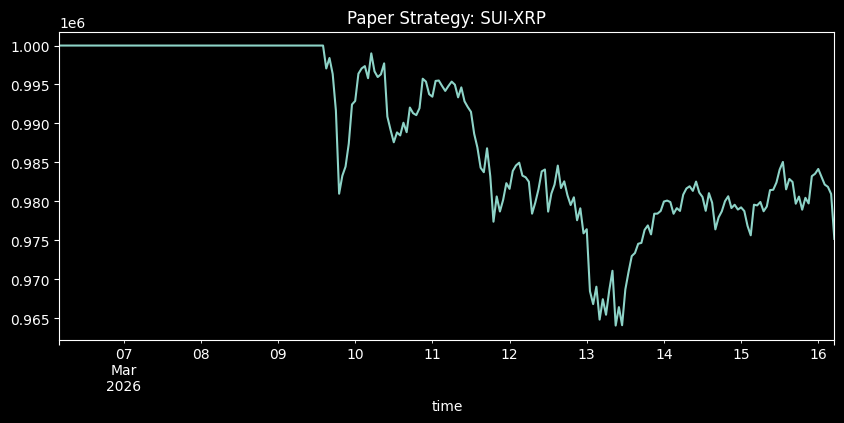


Testing AAVE-COMP with window=720...
--- Backtest Results for AAVE-COMP ---
Total Trades: 3
Final Equity: $1,054,235.31
Total Return: 5.42%
Max Drawdown Deactivated: False



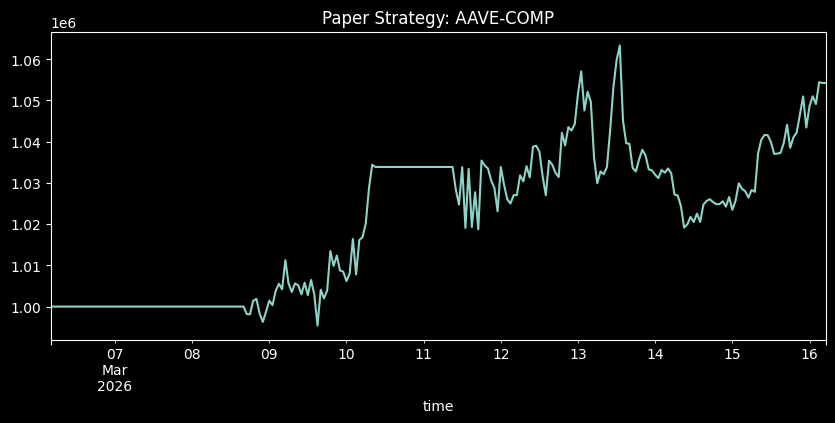


Testing IMX-SKL with window=720...
--- Backtest Results for IMX-SKL ---
Total Trades: 5
Final Equity: $1,059,088.33
Total Return: 5.91%
Max Drawdown Deactivated: False



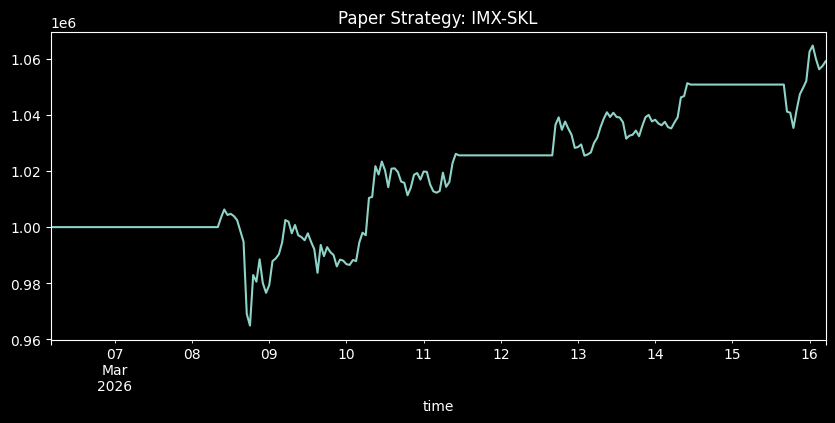


Testing LINK-COMP with window=720...
--- Backtest Results for LINK-COMP ---
Total Trades: 3
Final Equity: $996,656.76
Total Return: -0.33%
Max Drawdown Deactivated: False



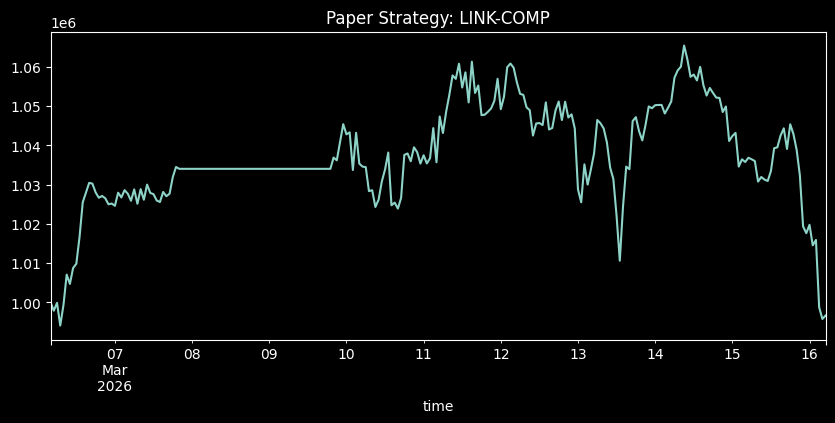


Testing ETH-XRP with window=360...
--- Backtest Results for ETH-XRP ---
Total Trades: 4
Final Equity: $1,013,885.11
Total Return: 1.39%
Max Drawdown Deactivated: False



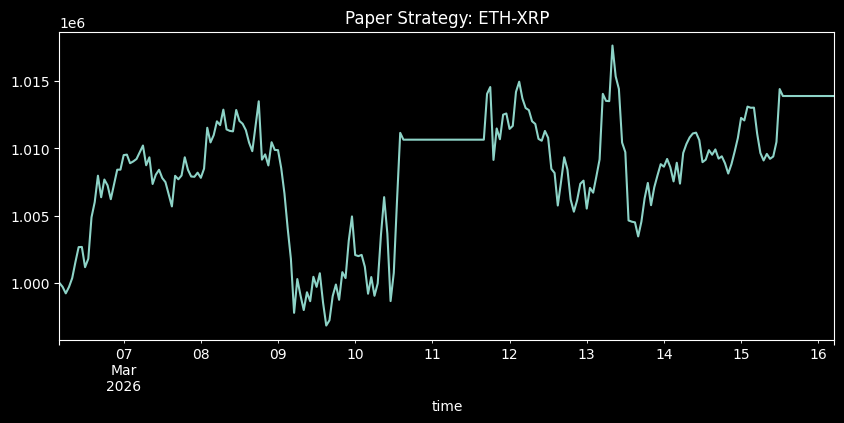


Testing ETH-SOL with window=360...
--- Backtest Results for ETH-SOL ---
Total Trades: 5
Final Equity: $994,861.00
Total Return: -0.51%
Max Drawdown Deactivated: False



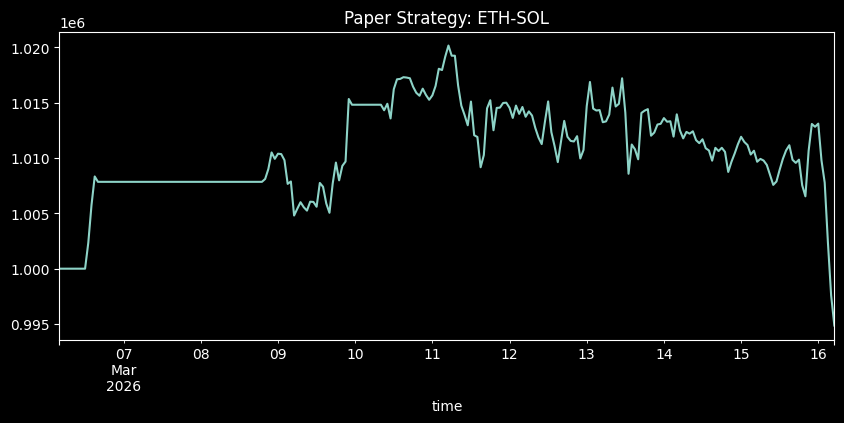


Testing SOL-XRP with window=168...
--- Backtest Results for SOL-XRP ---
Total Trades: 12
Final Equity: $1,037,971.34
Total Return: 3.80%
Max Drawdown Deactivated: False



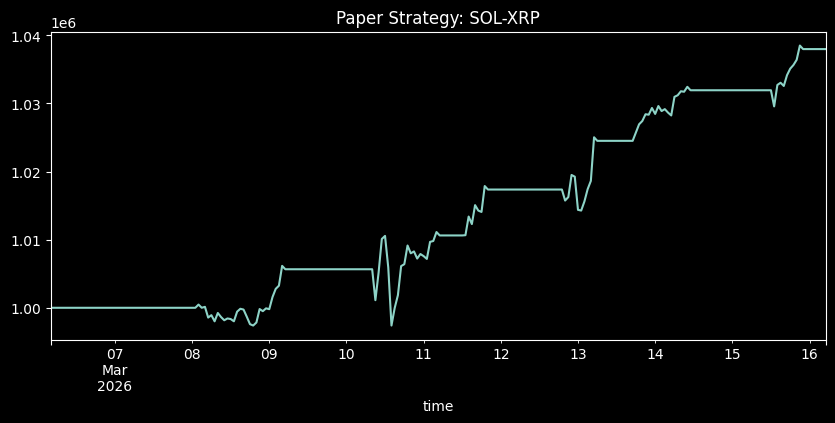


Testing BTC-ETH with window=360...
--- Backtest Results for BTC-ETH ---
Total Trades: 1
Final Equity: $988,220.82
Total Return: -1.18%
Max Drawdown Deactivated: False



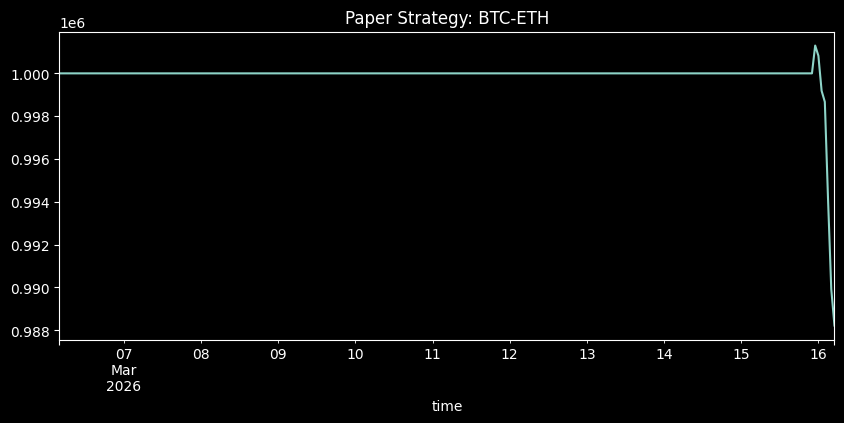


Testing AVAX-XRP with window=720...
--- Backtest Results for AVAX-XRP ---
Total Trades: 1
Final Equity: $951,703.72
Total Return: -4.83%
Max Drawdown Deactivated: False



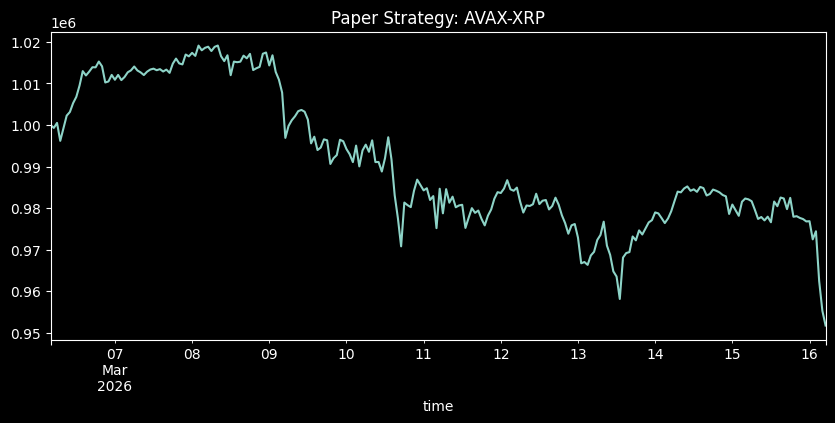


Testing ARB-SKL with window=720...
--- Backtest Results for ARB-SKL ---
Total Trades: 2
Final Equity: $1,052,542.82
Total Return: 5.25%
Max Drawdown Deactivated: False



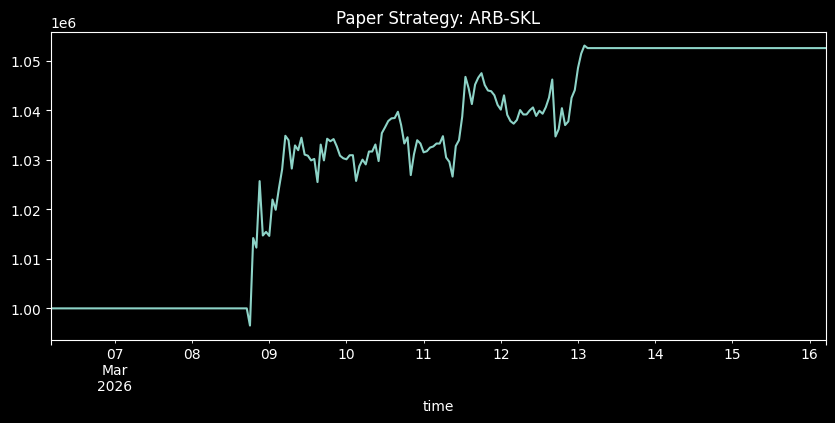


Testing BTC-SOL with window=720...
--- Backtest Results for BTC-SOL ---
Total Trades: 2
Final Equity: $1,007,850.19
Total Return: 0.79%
Max Drawdown Deactivated: False



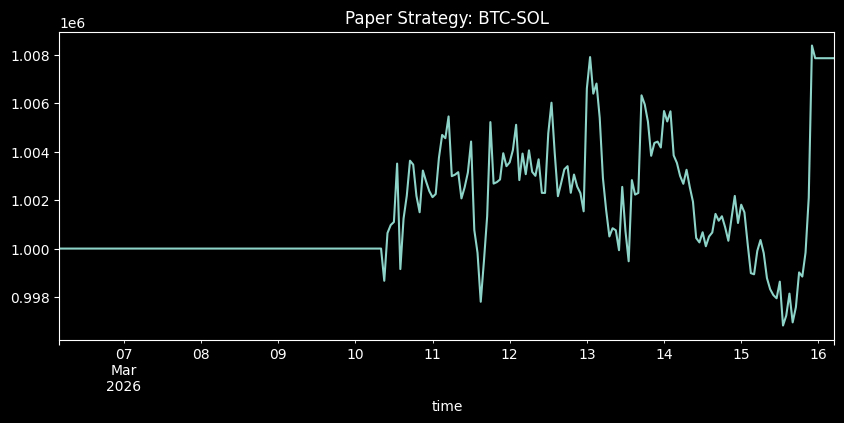


Testing DOT-NEAR with window=720...
--- Backtest Results for DOT-NEAR ---
Total Trades: 1
Final Equity: $1,031,346.19
Total Return: 3.13%
Max Drawdown Deactivated: False



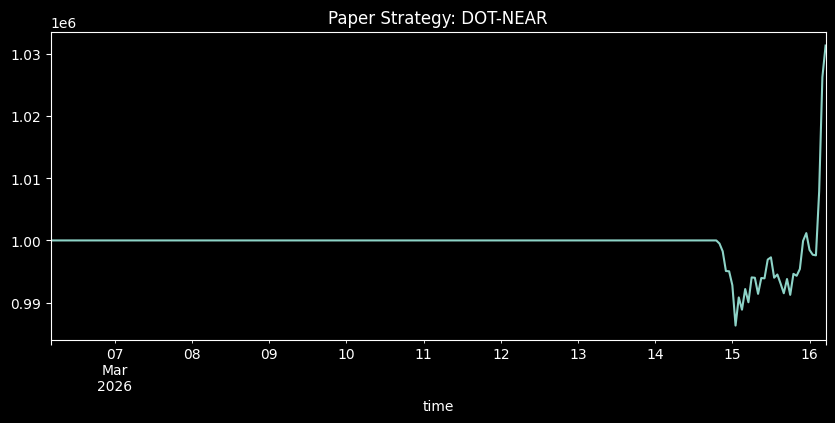


Testing LINK-CRV with window=720...
--- Backtest Results for LINK-CRV ---
Total Trades: 3
Final Equity: $964,320.57
Total Return: -3.57%
Max Drawdown Deactivated: False



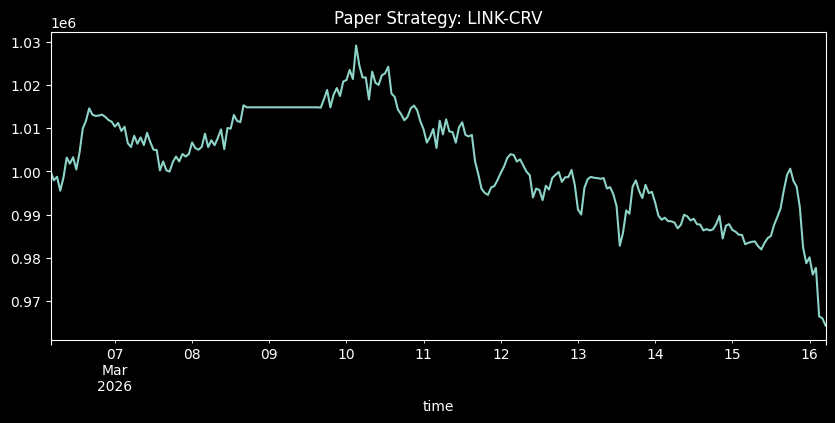


Testing XRP-DOGE with window=720...
--- Backtest Results for XRP-DOGE ---
Total Trades: 1
Final Equity: $1,005,821.27
Total Return: 0.58%
Max Drawdown Deactivated: False



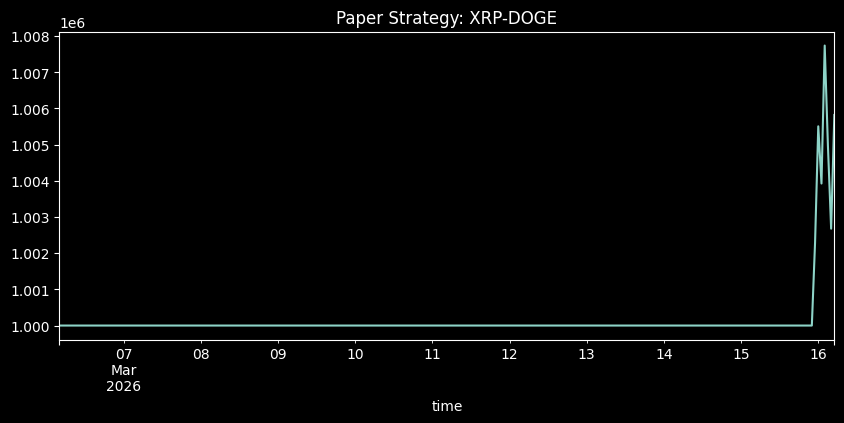


Testing SUI-DOGE with window=720...
--- Backtest Results for SUI-DOGE ---
Total Trades: 3
Final Equity: $997,598.01
Total Return: -0.24%
Max Drawdown Deactivated: False



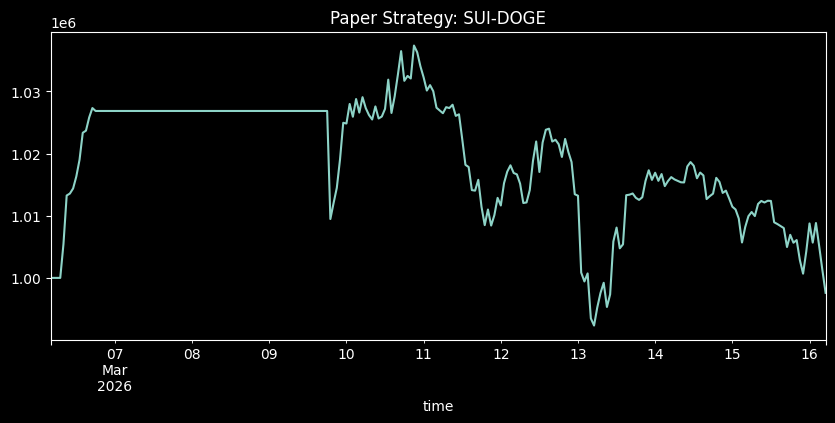


Testing BTC-BNB with window=360...
--- Backtest Results for BTC-BNB ---
Total Trades: 1
Final Equity: $996,679.63
Total Return: -0.33%
Max Drawdown Deactivated: False



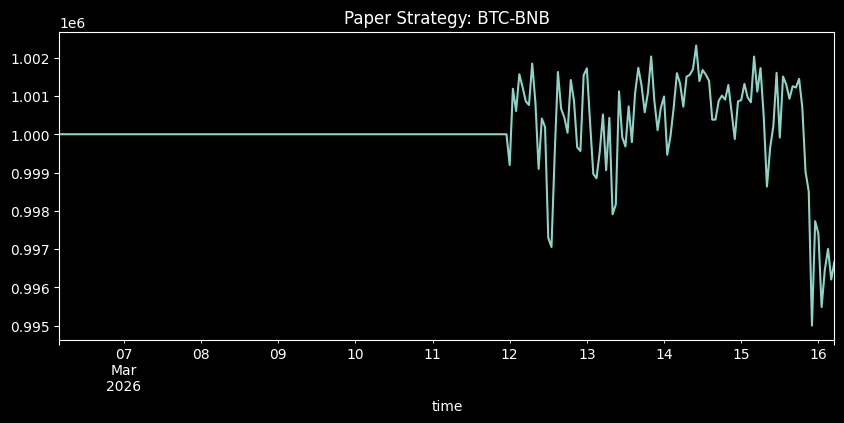


Testing SUI-AVAX with window=720...
--- Backtest Results for SUI-AVAX ---
Total Trades: 0
Final Equity: $1,000,000.00
Total Return: 0.00%
Max Drawdown Deactivated: False



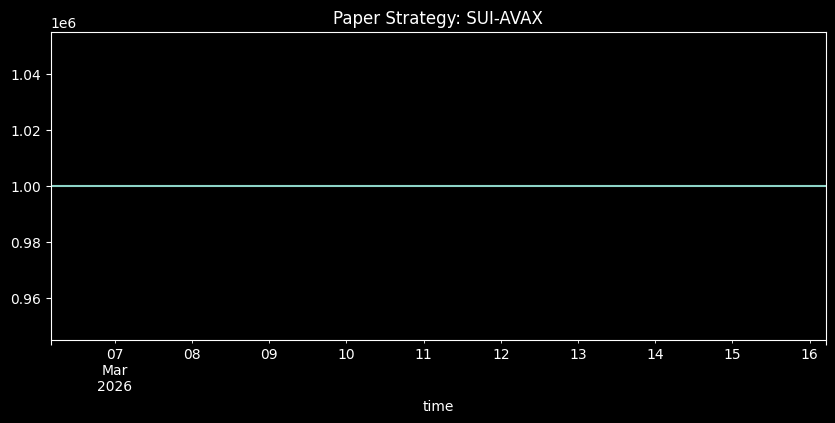

In [124]:
# Assuming 'results_df' is the dataframe from your IC test containing your top pairs
for index, row in results_df.iterrows():
    pair_str = row['Pair']
    coin_a, coin_b = pair_str.split('-')
    
    # Dynamically pull the Best T1 window found for this specific pair
    best_window = int(row['Best T1 (hours)'])
    
    warmup_data = train_close_prices.iloc[-best_window:]
    stitched_test_data = pd.concat([warmup_data, test_close_prices])
    stitched_test_data = stitched_test_data[~stitched_test_data.index.duplicated(keep='last')]
    
    print(f"\nTesting {coin_a}-{coin_b} with window={best_window}...")
    
    # Run the backtest using the stitched data and the dynamic window
    equity_curve, trade_history = run_paper_backtest(
        coin_a=coin_a, 
        coin_b=coin_b, 
        price_df=stitched_test_data, 
        window=best_window,    # <--- Now it uses the specific best window
        z_entry=1.5,           # You can still hardcode this or optimize it later
        z_exit=0.0      
    )
    
    # Note: The first 'best_window' hours will just be the bot doing math silently.
    # It will only start trading during the actual out-of-sample dates.
    
    # Plot the equity curve to visualize performance
    equity_curve['equity'].plot(figsize=(10, 4), title=f"Paper Strategy: {coin_a}-{coin_b}")
    plt.show()

# Long only backtest (competition setup)

In [125]:
def run_long_only_backtest(coin_a, coin_b, price_df, window=720, z_entry=2.0, z_exit=0.0, 
                           stop_loss_pct=0.15, cooldown_hours=120, starting_capital=100000.0, 
                           fee_rate=0.001):
    """
    Simulates a long-only relative value strategy on Roostoo mock exchange.
    Includes Total Return, Sharpe Ratio, and Sortino Ratio.
    """
    
    # 1. Calculate the rolling Z-Score
    log_prices = np.log(price_df[[coin_a, coin_b]]).dropna()
    y = log_prices[coin_a]
    x_col = log_prices[coin_b]
    X = sm.add_constant(x_col)
    
    roll_reg = RollingOLS(y, X, window=window).fit()
    params = roll_reg.params
    
    current_spread = y - (params['const'] + params[coin_b] * x_col)
    spread_std = np.sqrt(roll_reg.mse_resid)
    z_score = (current_spread / spread_std).dropna()
    
    aligned_prices = price_df.loc[z_score.index]
    
    # 2. Backtest State Tracking
    capital = starting_capital
    position = None 
    entry_price = 0.0
    units_held = 0.0
    cooldown_until = None
    
    equity_curve = []
    trades = []
    
    # 3. Time-Step Simulation
    for current_time, z in z_score.items():
        price_a = aligned_prices.loc[current_time, coin_a]
        price_b = aligned_prices.loc[current_time, coin_b]
        
        current_equity = capital
        if position == 'LONG_A':
            current_equity += units_held * price_a
        elif position == 'LONG_B':
            current_equity += units_held * price_b
            
        equity_curve.append({'time': current_time, 'equity': current_equity})
        
        if cooldown_until is not None and current_time < cooldown_until:
            continue
        elif cooldown_until is not None:
            cooldown_until = None
            
        if position is None:
            if z < -z_entry:
                position = 'LONG_A'
                entry_price = price_a
                units_held = (capital * (1 - fee_rate)) / entry_price
                capital = 0.0
                trades.append({'time': current_time, 'type': 'BUY_A', 'price': entry_price, 'z': z})
            elif z > z_entry:
                position = 'LONG_B'
                entry_price = price_b
                units_held = (capital * (1 - fee_rate)) / entry_price
                capital = 0.0
                trades.append({'time': current_time, 'type': 'BUY_B', 'price': entry_price, 'z': z})
        else:
            if position == 'LONG_A':
                unrealized_return = (price_a - entry_price) / entry_price
                if unrealized_return <= -stop_loss_pct:
                    capital = units_held * price_a * (1 - fee_rate)
                    units_held = 0.0
                    position = None
                    cooldown_until = current_time + pd.Timedelta(hours=cooldown_hours)
                    trades.append({'time': current_time, 'type': 'STOP_LOSS_A', 'price': price_a, 'return': unrealized_return})
                elif z >= -z_exit:
                    capital = units_held * price_a * (1 - fee_rate)
                    units_held = 0.0
                    position = None
                    trades.append({'time': current_time, 'type': 'SELL_A', 'price': price_a, 'return': unrealized_return})
            elif position == 'LONG_B':
                unrealized_return = (price_b - entry_price) / entry_price
                if unrealized_return <= -stop_loss_pct:
                    capital = units_held * price_b * (1 - fee_rate)
                    units_held = 0.0
                    position = None
                    cooldown_until = current_time + pd.Timedelta(hours=cooldown_hours)
                    trades.append({'time': current_time, 'type': 'STOP_LOSS_B', 'price': price_b, 'return': unrealized_return})
                elif z <= z_exit:
                    capital = units_held * price_b * (1 - fee_rate)
                    units_held = 0.0
                    position = None
                    trades.append({'time': current_time, 'type': 'SELL_B', 'price': price_b, 'return': unrealized_return})

    # 4. Wrap up results and calculate Risk Metrics
    equity_df = pd.DataFrame(equity_curve).set_index('time')
    trades_df = pd.DataFrame(trades)
    
    # Calculate returns for Sharpe/Sortino
    # Assuming data is hourly, annualize by sqrt(24 * 365)
    returns = equity_df['equity'].pct_change().dropna()
    ann_factor = np.sqrt(24 * 365) 
    
    sharpe_ratio = 0
    sortino_ratio = 0
    
    if len(returns) > 0 and returns.std() != 0:
        sharpe_ratio = (returns.mean() / returns.std()) * ann_factor
        
        downside_returns = returns[returns < 0]
        if len(downside_returns) > 0 and downside_returns.std() != 0:
            sortino_ratio = (returns.mean() / downside_returns.std()) * ann_factor

    total_return = (equity_df['equity'].iloc[-1] - starting_capital) / starting_capital
    
    print(f"--- Backtest Results for {coin_a}-{coin_b} ---")
    print(f"Total Trades: {len(trades_df)}")
    print(f"Total Return: {total_return * 100:.2f}%")
    print(f"Sharpe Ratio: {sharpe_ratio:.4f}")
    print(f"Sortino Ratio: {sortino_ratio:.4f}")
    print(f"Final Equity: ${equity_df['equity'].iloc[-1]:.2f}\n")
    
    return equity_df, trades_df, sharpe_ratio


Testing SUI-XRP with window=720...
--- Backtest Results for SUI-XRP ---
Total Trades: 1
Total Return: 8.42%
Sharpe Ratio: 6.7902
Sortino Ratio: 9.5107
Final Equity: $108420.82



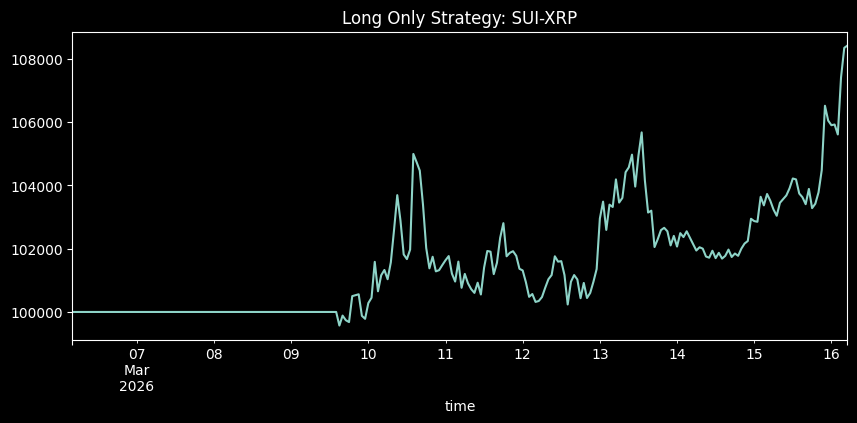


Testing AAVE-COMP with window=720...
--- Backtest Results for AAVE-COMP ---
Total Trades: 3
Total Return: 15.01%
Sharpe Ratio: 9.2918
Sortino Ratio: 12.2221
Final Equity: $115006.94



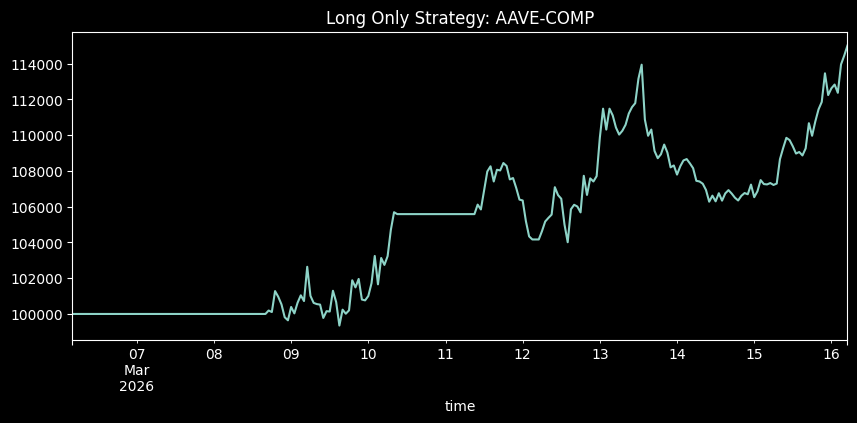


Testing IMX-SKL with window=720...
--- Backtest Results for IMX-SKL ---
Total Trades: 5
Total Return: 9.04%
Sharpe Ratio: 6.1355
Sortino Ratio: 9.6974
Final Equity: $109042.91



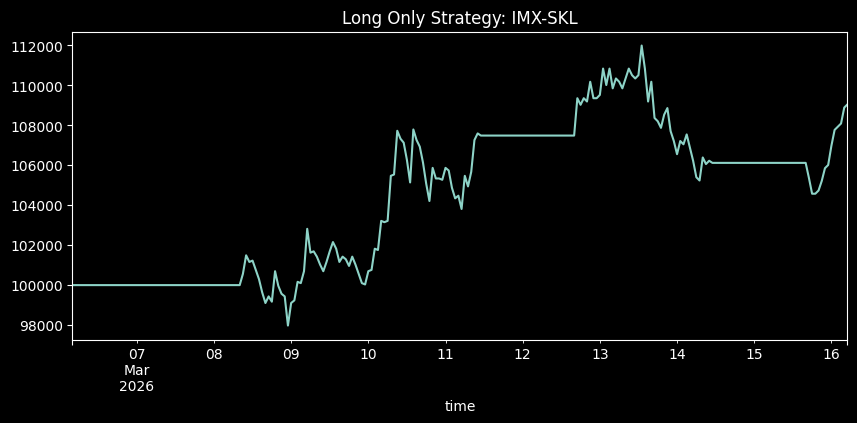


Testing LINK-COMP with window=720...
--- Backtest Results for LINK-COMP ---
Total Trades: 3
Total Return: 11.35%
Sharpe Ratio: 5.6553
Sortino Ratio: 7.5736
Final Equity: $111350.75



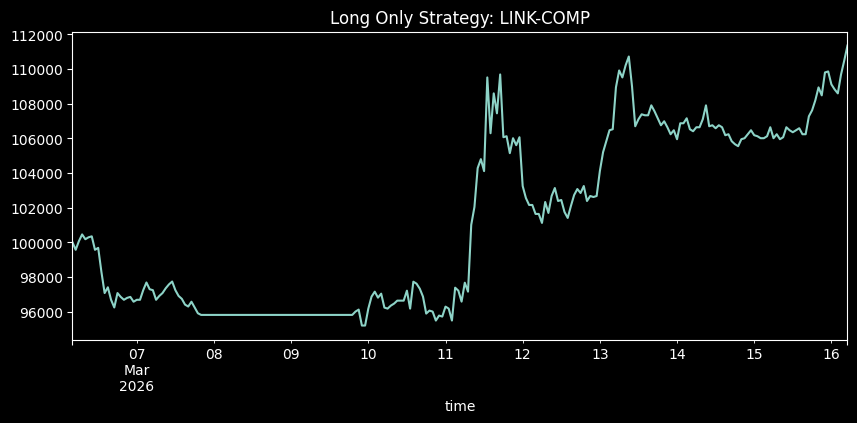


Testing ETH-XRP with window=360...
--- Backtest Results for ETH-XRP ---
Total Trades: 4
Total Return: 4.77%
Sharpe Ratio: 4.0271
Sortino Ratio: 6.0631
Final Equity: $104770.55



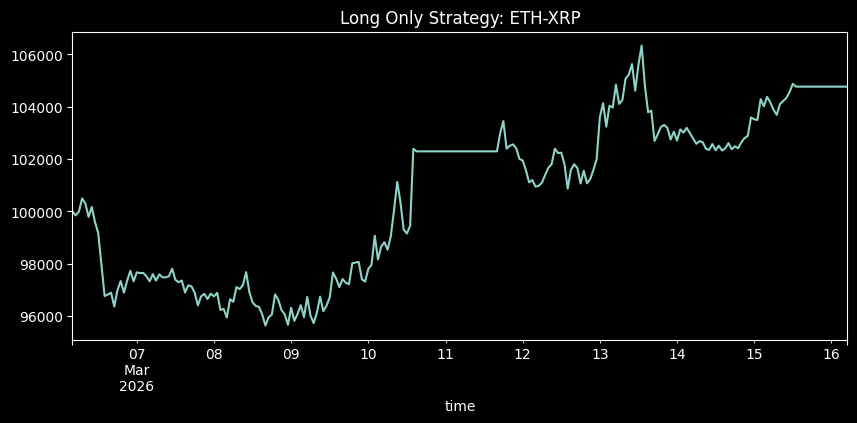


Testing ETH-SOL with window=360...
--- Backtest Results for ETH-SOL ---
Total Trades: 5
Total Return: 9.73%
Sharpe Ratio: 6.1777
Sortino Ratio: 9.1238
Final Equity: $109733.03



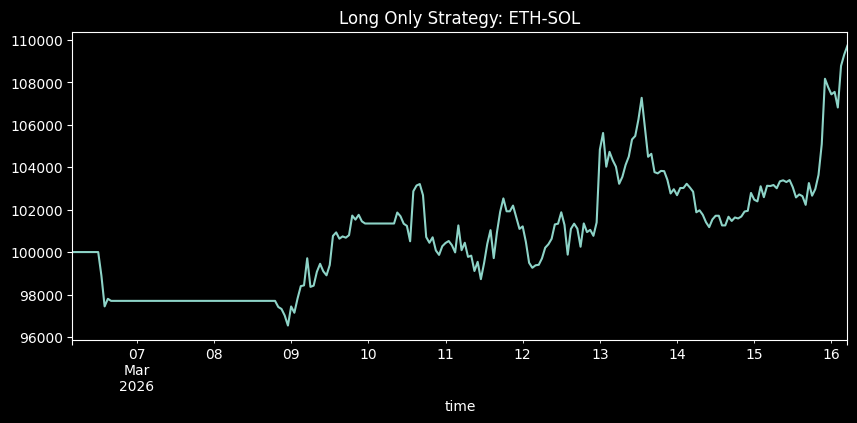


Testing SOL-XRP with window=168...
--- Backtest Results for SOL-XRP ---
Total Trades: 12
Total Return: 6.50%
Sharpe Ratio: 6.4100
Sortino Ratio: 7.0887
Final Equity: $106502.53



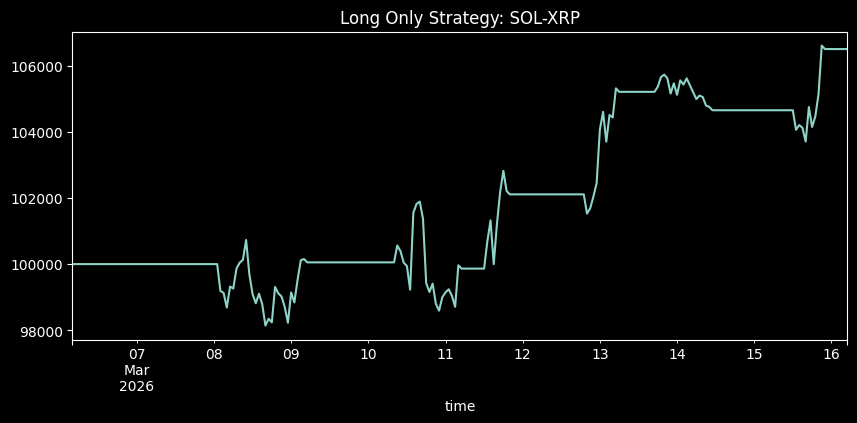


Testing BTC-ETH with window=360...
--- Backtest Results for BTC-ETH ---
Total Trades: 1
Total Return: 1.81%
Sharpe Ratio: 6.5478
Sortino Ratio: 3.4499
Final Equity: $101814.15



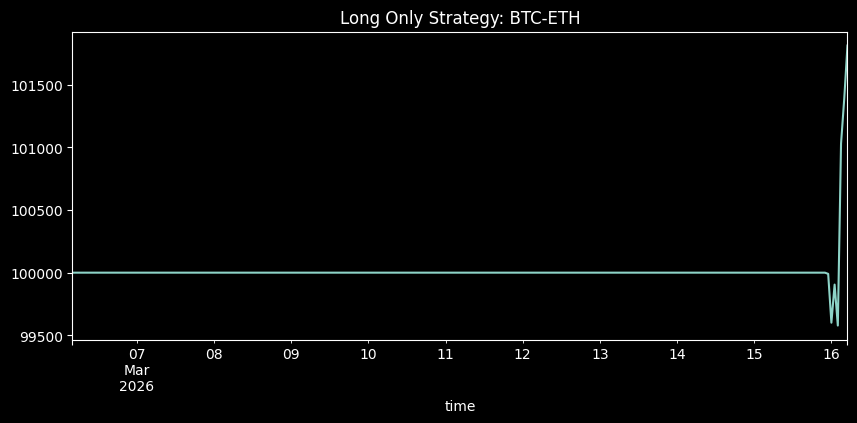


Testing AVAX-XRP with window=720...
--- Backtest Results for AVAX-XRP ---
Total Trades: 1
Total Return: 5.74%
Sharpe Ratio: 4.2423
Sortino Ratio: 7.2739
Final Equity: $105739.93



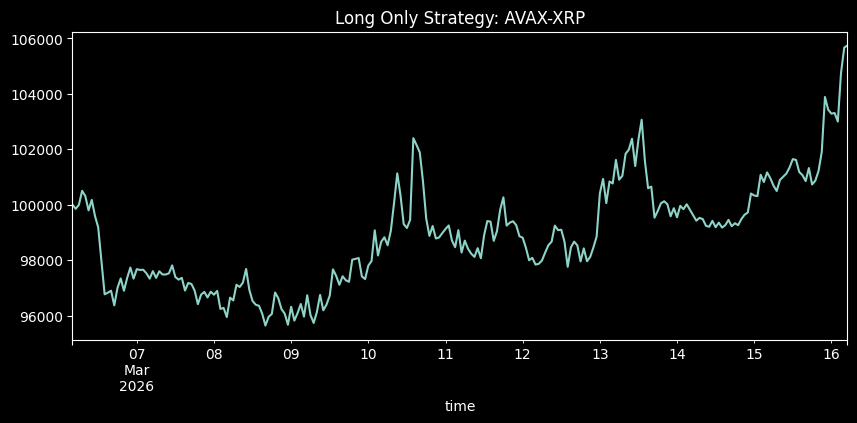


Testing ARB-SKL with window=720...
--- Backtest Results for ARB-SKL ---
Total Trades: 2
Total Return: 8.52%
Sharpe Ratio: 6.7537
Sortino Ratio: 7.5662
Final Equity: $108519.48



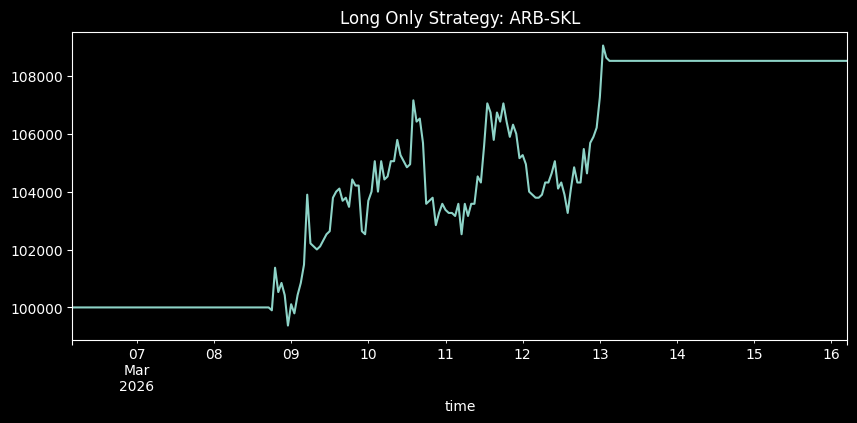


Testing BTC-SOL with window=720...
--- Backtest Results for BTC-SOL ---
Total Trades: 2
Total Return: 6.63%
Sharpe Ratio: 4.7931
Sortino Ratio: 6.3348
Final Equity: $106625.32



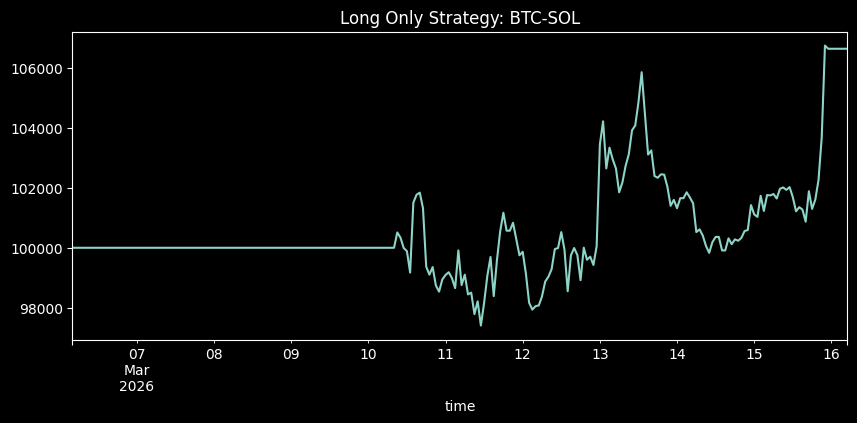


Testing DOT-NEAR with window=720...
--- Backtest Results for DOT-NEAR ---
Total Trades: 1
Total Return: 8.95%
Sharpe Ratio: 11.0049
Sortino Ratio: 13.7031
Final Equity: $108949.68



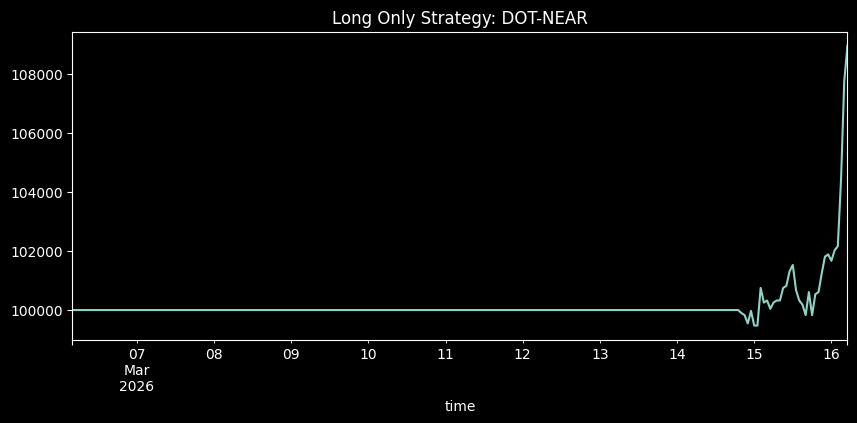


Testing LINK-CRV with window=720...
--- Backtest Results for LINK-CRV ---
Total Trades: 3
Total Return: -5.99%
Sharpe Ratio: -3.2094
Sortino Ratio: -4.8394
Final Equity: $94013.07



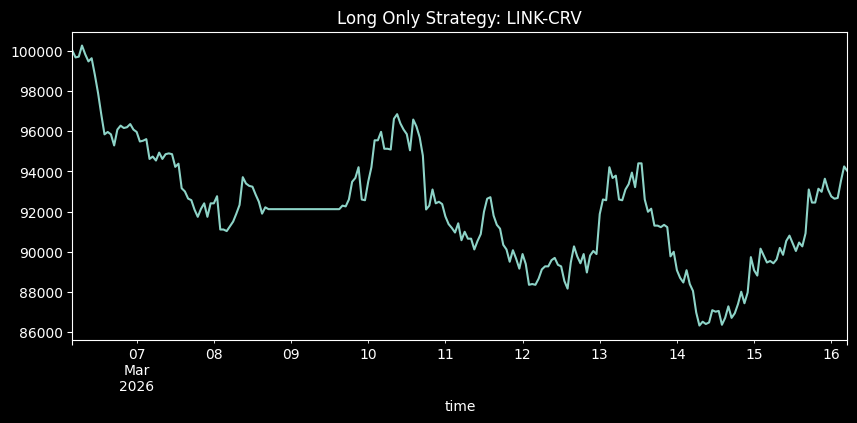


Testing XRP-DOGE with window=720...
--- Backtest Results for XRP-DOGE ---
Total Trades: 1
Total Return: 4.25%
Sharpe Ratio: 10.6541
Sortino Ratio: 7.7183
Final Equity: $104251.06



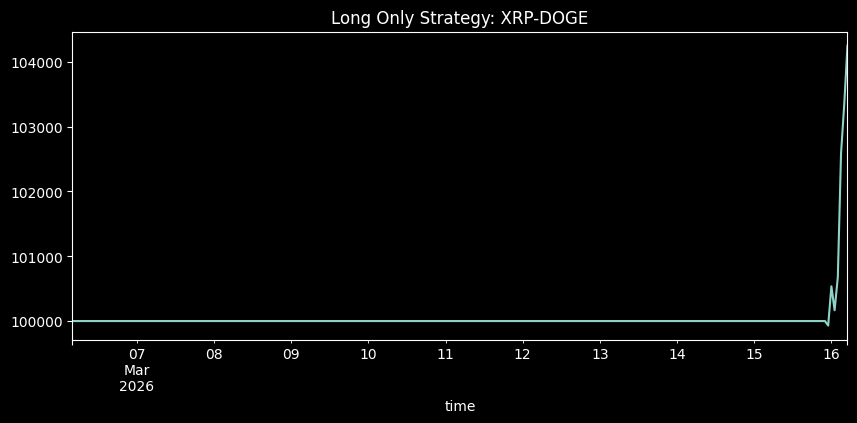


Testing SUI-DOGE with window=720...
--- Backtest Results for SUI-DOGE ---
Total Trades: 3
Total Return: 7.09%
Sharpe Ratio: 4.4040
Sortino Ratio: 5.2411
Final Equity: $107086.47



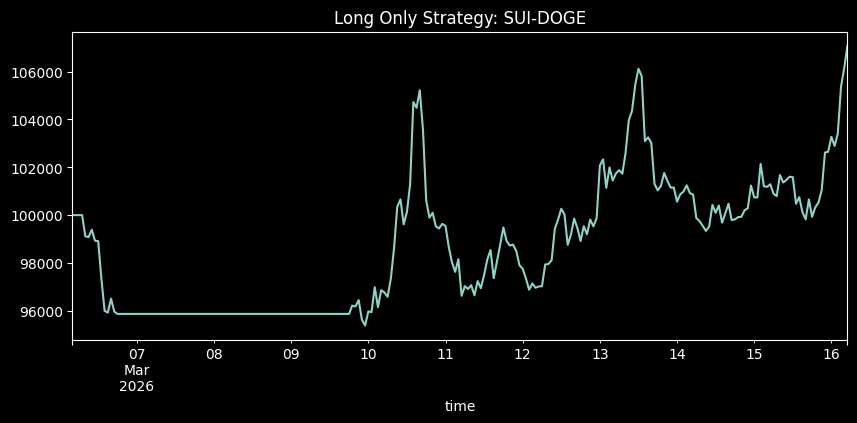


Testing BTC-BNB with window=360...
--- Backtest Results for BTC-BNB ---
Total Trades: 1
Total Return: 5.52%
Sharpe Ratio: 7.1973
Sortino Ratio: 6.8736
Final Equity: $105523.95



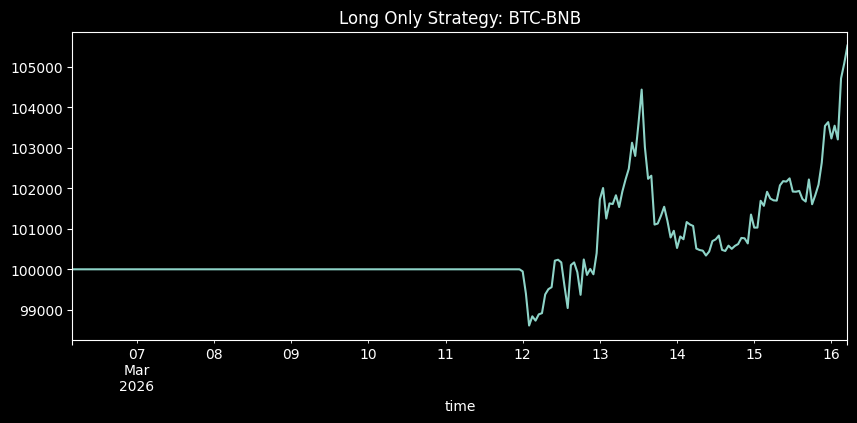


Testing SUI-AVAX with window=720...
--- Backtest Results for SUI-AVAX ---
Total Trades: 0
Total Return: 0.00%
Sharpe Ratio: 0.0000
Sortino Ratio: 0.0000
Final Equity: $100000.00



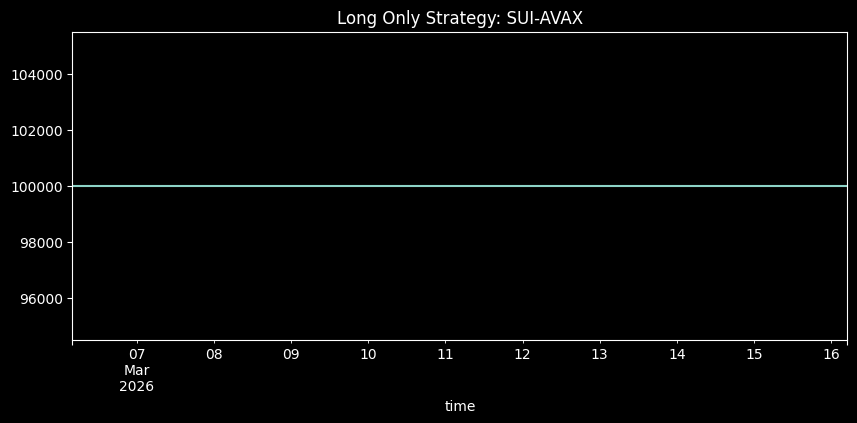

In [126]:
# Assuming 'results_df' is the dataframe from your IC test containing your top pairs
# We will iterate through the top 4 rows
for index, row in results_df.iterrows():
    pair_str = row['Pair']
    coin_a, coin_b = pair_str.split('-')
    
    # Dynamically pull the Best T1 window found for this specific pair
    best_window = int(row['Best T1 (hours)'])
    
    # --- THE WARM-UP FIX ---
    # Take the exact number of hours needed from the END of the training set
    warmup_data = train_close_prices.iloc[-best_window:]
    
    # Attach the test set to the end of the warm-up data
    stitched_test_data = pd.concat([warmup_data, test_close_prices])
    # -----------------------
    
    print(f"\nTesting {coin_a}-{coin_b} with window={best_window}...")
    
    # Run the backtest using the stitched data and the dynamic window
    equity_curve, trade_history, sharpe_ratio = run_long_only_backtest(
        coin_a=coin_a, 
        coin_b=coin_b, 
        price_df=stitched_test_data, 
        window=best_window,    # <--- Now it uses the specific best window
        z_entry=1.5,           # You can still hardcode this or optimize it later
        z_exit=0.0      
    )
    
    # Note: The first 'best_window' hours will just be the bot doing math silently.
    # It will only start trading during the actual out-of-sample dates.
    
    # Plot the equity curve to visualize performance
    equity_curve['equity'].plot(figsize=(10, 4), title=f"Long Only Strategy: {coin_a}-{coin_b}")
    plt.show()

### Further optimization: grid search to find best z-score for each pair
This might be overfitting a bit but just testing out of curiosity

In [127]:
def grid_search_z_params(coin_a, coin_b, price_df, window=720, 
                        z_entry_range=[1.5, 2.0, 2.5, 3.0], 
                        z_exit_range=[0.0, 0.5, 1.0]):
    """
    Performs a grid search to find the optimal z_entry and z_exit parameters.
    """
    results = []
    
    print(f"Starting Grid Search for {coin_a}-{coin_b}...")
    
    for z_entry in z_entry_range:
        for z_exit in z_exit_range:
            # We only care about cases where the entry barrier is wider than the exit
            if z_exit >= z_entry:
                continue
                
            equity_df, trades_df, sharpe_ratio = run_long_only_backtest(
                coin_a=coin_a,
                coin_b=coin_b,
                price_df=price_df,
                window=window,
                z_entry=z_entry,
                z_exit=z_exit,
                starting_capital=100000.0
            )
            
            # Calculate metrics
            final_equity = equity_df['equity'].iloc[-1]
            total_return = (final_equity - 100000.0) / 100000.0
            num_trades = len(trades_df)
            
            results.append({
                'z_entry': z_entry,
                'z_exit': z_exit,
                'total_return': total_return,
                'sharpe_ratio': sharpe_ratio,
                'num_trades': num_trades,
                'final_equity': final_equity
            })
            
            print(f"Tested: z_entry={z_entry}, z_exit={z_exit} | Return: {total_return*100:.2f}% | Sharpe: {sharpe_ratio} | Trades: {num_trades}")

    results_df = pd.DataFrame(results)
    
    if not results_df.empty:
        best_result = results_df.sort_values(by='sharpe_ratio', ascending=False).iloc[0]
        print("\n" + "="*30)
        print("--- Best Parameters Found ---")
        print(f"z_entry: {best_result['z_entry']}")
        print(f"z_exit:  {best_result['z_exit']}")
        print(f"Sharpe: {best_result['sharpe_ratio']}")
        print(f"Total Return: {best_result['total_return']*100:.2f}%")
        print(f"Number of Trades: {best_result['num_trades']}")
        print("="*30)
    
    return results_df

In [128]:
# Assuming 'results_df' is the dataframe from your IC test containing your top pairs
# We will iterate through the top 4 rows
for index, row in results_df.iterrows():
    pair_str = row['Pair']
    coin_a, coin_b = pair_str.split('-')
    
    # Dynamically pull the Best T1 window found for this specific pair
    best_window = int(row['Best T1 (hours)'])
    
    print(f"Grid-searching z-score for {coin_a}-{coin_b} with window={best_window}...")
    
    # Run the backtest using the stitched data and the dynamic window
    gs_results = grid_search_z_params(
        coin_a=coin_a, 
        coin_b=coin_b, 
        price_df=train_close_prices, 
        window=best_window,    # <--- Now it uses the specific best window
    )

Grid-searching z-score for SUI-XRP with window=720...
Starting Grid Search for SUI-XRP...
--- Backtest Results for SUI-XRP ---
Total Trades: 10
Total Return: -35.70%
Sharpe Ratio: -5.5875
Sortino Ratio: -4.5539
Final Equity: $64300.07

Tested: z_entry=1.5, z_exit=0.0 | Return: -35.70% | Sharpe: -5.5874624374162645 | Trades: 10
--- Backtest Results for SUI-XRP ---
Total Trades: 12
Total Return: -30.51%
Sharpe Ratio: -4.9590
Sortino Ratio: -3.6093
Final Equity: $69485.43

Tested: z_entry=1.5, z_exit=0.5 | Return: -30.51% | Sharpe: -4.959044441578259 | Trades: 12
--- Backtest Results for SUI-XRP ---
Total Trades: 18
Total Return: -32.36%
Sharpe Ratio: -6.1240
Sortino Ratio: -3.7894
Final Equity: $67637.81

Tested: z_entry=1.5, z_exit=1.0 | Return: -32.36% | Sharpe: -6.123991918521053 | Trades: 18
--- Backtest Results for SUI-XRP ---
Total Trades: 10
Total Return: -37.16%
Sharpe Ratio: -6.1684
Sortino Ratio: -4.6142
Final Equity: $62842.82

Tested: z_entry=2.0, z_exit=0.0 | Return: -37.16%

# Final backtest: Simulate entire portfolio (long-only)
Assuming each pair gets an equal capital allocation

Starting aggregated portfolio backtest for 17 pairs...
Allocation per pair: $58,823.53

--- Backtest Results for SUI-XRP ---
Total Trades: 1
Total Return: 8.42%
Sharpe Ratio: 6.7902
Sortino Ratio: 9.5107
Final Equity: $63776.95

--- Backtest Results for AAVE-COMP ---
Total Trades: 6
Total Return: 16.77%
Sharpe Ratio: 11.4888
Sortino Ratio: 15.6174
Final Equity: $68689.23

--- Backtest Results for IMX-SKL ---
Total Trades: 5
Total Return: 9.35%
Sharpe Ratio: 7.3083
Sortino Ratio: 9.3478
Final Equity: $64321.50

--- Backtest Results for LINK-COMP ---
Total Trades: 7
Total Return: 9.74%
Sharpe Ratio: 7.2766
Sortino Ratio: 8.0807
Final Equity: $64554.72

--- Backtest Results for ETH-XRP ---
Total Trades: 1
Total Return: 6.29%
Sharpe Ratio: 6.7350
Sortino Ratio: 7.2932
Final Equity: $62521.66

--- Backtest Results for ETH-SOL ---
Total Trades: 1
Total Return: 8.44%
Sharpe Ratio: 7.3460
Sortino Ratio: 8.8902
Final Equity: $63787.33

--- Backtest Results for SOL-XRP ---
Total Trades: 1
Total 

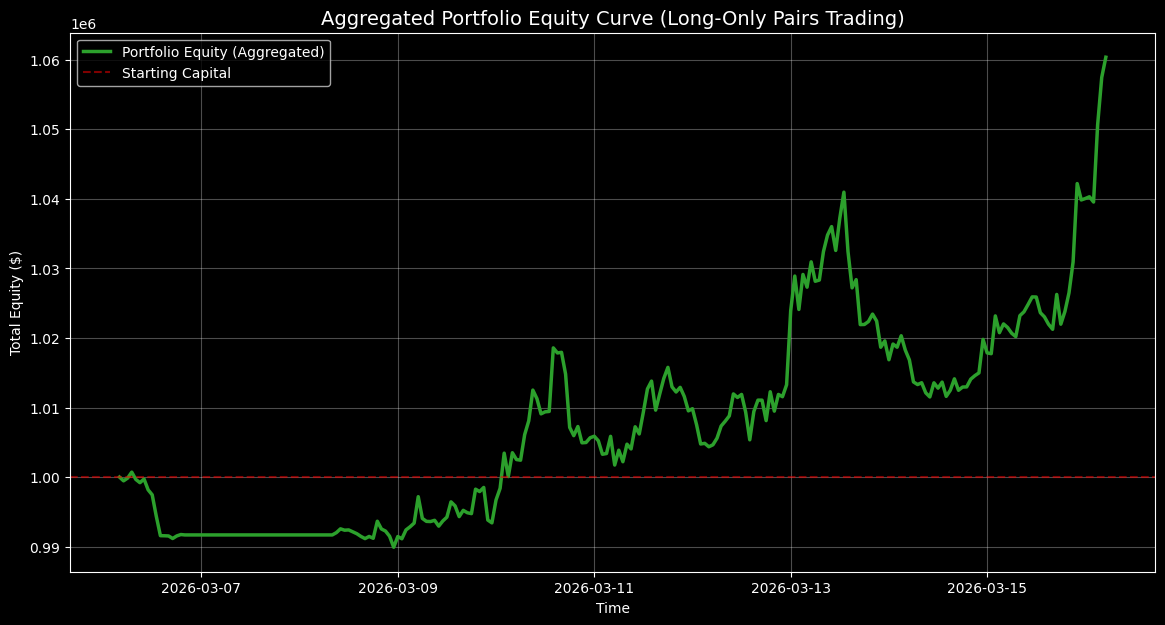

In [129]:
# 2. Portfolio Configuration
total_portfolio_capital = 1000000.0  # $1,000,000 for the whole portfolio
capital_per_pair = total_portfolio_capital / len(results_df)

individual_equities = []
all_trades = []

print(f"Starting aggregated portfolio backtest for {len(results_df)} pairs...")
print(f"Allocation per pair: ${capital_per_pair:,.2f}\n")

for idx, row in results_df.iterrows():
    pair_name = row['Pair']
    coin_a, coin_b = pair_name.split('-')
    best_window = int(row['Best T1 (hours)'])
    
    # Run backtest for this specific pair
    # Note: Using fixed z_entry=2.0, z_exit=0.0 as robust defaults, 
    # but you can swap these for grid-search results if you have them.
    equity_df, trades_df, sharpe_ratio = run_long_only_backtest(
        coin_a=coin_a,
        coin_b=coin_b,
        price_df=stitched_test_data,
        window=720,
        z_entry=1.5,
        z_exit=0.5,
        starting_capital=capital_per_pair
    )
    
    # Rename column to avoid collision when merging
    equity_series = equity_df['equity'].rename(f'equity_{pair_name}')
    individual_equities.append(equity_series)
    all_trades.append(trades_df)

# 3. Aggregate results into a single DataFrame
portfolio_equity_df = pd.concat(individual_equities, axis=1)
# Forward fill missing values (if some pairs start trading later than others)
portfolio_equity_df = portfolio_equity_df.ffill().dropna()

# Sum all individual pair equities to get total portfolio equity
portfolio_equity_df['total_equity'] = portfolio_equity_df.sum(axis=1)

# 4. Calculate Aggregate Risk Metrics
p_returns = portfolio_equity_df['total_equity'].pct_change().dropna()
# Hourly data annualization factor
ann_factor = np.sqrt(24 * 365) 

p_sharpe = 0
p_sortino = 0
if p_returns.std() != 0:
    p_sharpe = (p_returns.mean() / p_returns.std()) * ann_factor
    
    p_downside = p_returns[p_returns < 0]
    if len(p_downside) > 0 and p_downside.std() != 0:
        p_sortino = (p_returns.mean() / p_downside.std()) * ann_factor

final_portfolio_equity = portfolio_equity_df['total_equity'].iloc[-1]
portfolio_total_return = (final_portfolio_equity - total_portfolio_capital) / total_portfolio_capital

# 5. Display Summary
print("\n" + "="*45)
print("--- AGGREGATED PORTFOLIO PERFORMANCE ---")
print(f"Initial Investment: ${total_portfolio_capital:,.2f}")
print(f"Final Equity:      ${final_portfolio_equity:,.2f}")
print(f"Total Return:      {portfolio_total_return * 100:.2f}%")
print(f"Portfolio Sharpe:  {p_sharpe:.4f}")
print(f"Portfolio Sortino: {p_sortino:.4f}")
print(f"Total Combined Trades: {sum(len(t) for t in all_trades)}")
print("="*45)

# 6. Plot the Portfolio Equity Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(portfolio_equity_df['total_equity'], label='Portfolio Equity (Aggregated)', color='#2ca02c', linewidth=2.5)
plt.axhline(y=total_portfolio_capital, color='red', linestyle='--', alpha=0.5, label='Starting Capital')
plt.title('Aggregated Portfolio Equity Curve (Long-Only Pairs Trading)', fontsize=14)
plt.ylabel('Total Equity ($)')
plt.xlabel('Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
